# 4. Implementation of fuzzy logic. 

In [3]:
import numpy as np
import skfuzzy as fuzz

-----------------------
STEP 1: Define the universe of discourse
 
-----------------------
Let's say Temperature can range from 0 to 20 (in °C)
 and Fan Speed can range from 0 to 40 (some arbitrary speed units).

In [6]:
temperature = np.arange(0, 21, 1)
fan_speed = np.arange(0, 41, 1)

-----------------------
STEP 2: Define fuzzy membership functions for temperature

-----------------------
We'll use triangular membership functions (trimf). <br>
`Syntax: fuzz.trimf(universe, [start, peak, end])`

In [7]:
temp_low = fuzz.trimf(temperature, [0, 0 ,10])
temp_moderate = fuzz.trimf(temperature, [0, 10, 20])
temp_high = fuzz.trimf(temperature, [10, 20, 20])

 -----------------------
STEP 3: Define fuzzy membership functions for fan speed

-----------------------

In [8]:
fan_slow = fuzz.trimf(fan_speed, [0, 0, 20])
fan_medium = fuzz.trimf(fan_speed, [0, 20, 40])
fan_fast = fuzz.trimf(fan_speed, [20, 40, 40])

 -----------------------
STEP 4: Fuzzify the input

-----------------------
Suppose the actual temperature is 15°C. <br>
We find out how "low", "moderate", and "high" this temperature is. <br>
temp_input_value = 15 <br>
```fuzz.interp_membership(universe, membership_function, crisp_value) ``` <br>
```returns the membership degree in [0,1]```

In [9]:
temp_input_value = 15

In [10]:
temp_low_degree = fuzz.interp_membership(temperature, temp_low, temp_input_value)
temp_moderate_degree = fuzz.interp_membership(temperature, temp_moderate, temp_input_value)
temp_high_degree = fuzz.interp_membership(temperature, temp_high, temp_input_value)

In [13]:
print(f"Temperature = {temp_input_value}°C")
print(f" - Low membership    = {temp_low_degree:.2f}")
print(f" - Moderate membership = {temp_moderate_degree:.2f}")
print(f" - High membership   = {temp_high_degree:.2f}")

Temperature = 15°C
 - Low membership    = 0.00
 - Moderate membership = 0.50
 - High membership   = 0.50



-----------------------

STEP 5: Define fuzzy rules

-----------------------

Let's define simple rules:
1) IF Temperature is Low      THEN Fan Speed is Slow
2) IF Temperature is Moderate THEN Fan Speed is Medium

3) IF Temperature is High     THEN Fan Speed is Fast
- The membership degree of each rule’s output is the same as the membership degree of the corresponding temperature set

In [14]:
fan_slow_degree = temp_low_degree
fan_medium_degree = temp_moderate_degree
fan_fast_degree = temp_high_degree

-----------------------
STEP 6: Aggregate the outputs

-----------------------
- We combine (OR) the three outputs into a single fuzzy set
that covers the entire fan_speed range from 0 to 40.
- A simple way is to create membership functions scaled by the rule strengths.
- For each segment (slow, medium, fast), we cut its membership function at the rule’s strength.
- The result is a fuzzy set describing the possible fan speeds.

- "np.fmin" is often used to truncate the membership function by the rule’s degree.

In [26]:
fan_slow_degree, fan_slow

(0.0,
 array([1.  , 0.95, 0.9 , 0.85, 0.8 , 0.75, 0.7 , 0.65, 0.6 , 0.55, 0.5 ,
        0.45, 0.4 , 0.35, 0.3 , 0.25, 0.2 , 0.15, 0.1 , 0.05, 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]))

In [17]:
fan_slow_activation = np.fmin(fan_slow_degree, fan_slow)
fan_medium_activation = np.fmin(fan_medium_degree, fan_medium)
fan_fast_activation = np.fmin(fan_fast_degree, fan_fast)

In [22]:
# Combine them with a fuzzy OR (maximum)
aggregated = np.fmax(fan_slow_activation,
                    np.fmax(fan_medium_activation, fan_fast_activation))
aggregated

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.5 , 0.5 , 0.5 , 0.5 , 0.5 , 0.5 , 0.5 , 0.5 , 0.5 , 0.5 , 0.5 ,
       0.5 , 0.5 , 0.5 , 0.5 , 0.5 , 0.5 , 0.5 , 0.5 , 0.5 , 0.5 , 0.5 ,
       0.5 , 0.5 , 0.5 , 0.5 , 0.5 , 0.5 , 0.5 , 0.5 ])


-----------------------
STEP 7: Defuzzify

-----------------------
- We convert the aggregated fuzzy output to a crisp value (fan_speed_output)
using the Centroid (center of gravity) method.

In [23]:
fan_speed_output = fuzz.defuzz(fan_speed, aggregated, 'centroid')

# If you want the membership value of that crisp output:
fan_speed_membership = fuzz.interp_membership(fan_speed, aggregated, fan_speed_output)

In [24]:
print(f"\nAggregated membership for fan speeds is now a fuzzy set.")
print(f"Defuzzified fan speed = {fan_speed_output:.2f}")
print(f"Membership at that speed = {fan_speed_membership:.2f}")


Aggregated membership for fan speeds is now a fuzzy set.
Defuzzified fan speed = 22.38
Membership at that speed = 0.50


---
---
# 5. Hebb Rule

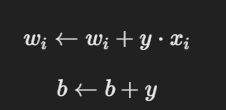

In [28]:
import numpy as np

In [29]:
# -----------------------------
# Step 1: Define the input patterns and their targets
# -----------------------------
# Suppose we have two input patterns, each of length 9:

x1 = np.array([1, 1, 1, -1, 1, -1, 1, 1, 1])
x2 = np.array([1, -1, -1, 1, -1, 1, -1, 1, -1])

In [30]:
# Targets for each pattern
y1 = +1
y2 = -1

In [31]:
# -----------------------------
# Step 2: Initialize weights and bias
# -----------------------------
# Start with all weights = 0, bias = 0

w = np.zeros(9, dtype = int)
b = 0

In [34]:
# -----------------------------
# Step 3: Apply Hebb’s rule for the first pattern (x1, y1 = +1)
# -----------------------------
# Hebb's update: w_new = w_old + y1 * x1
#               b_new = b_old + y1

w_new = w + y1 * x1
b_new = b + y1

print("After training on first pattern (target = +1):")
print("Updated weights:", w_new)
print("Updated bias:", b_new)
print("--------------------------------------------------")

After training on first pattern (target = +1):
Updated weights: [ 1  1  1 -1  1 -1  1  1  1]
Updated bias: 1
--------------------------------------------------


In [35]:
# -----------------------------
# Step 4: Apply Hebb’s rule for the second pattern (x2, y2 = -1)
# -----------------------------
# Hebb's update: w_new = w_old + y2 * x2
#               b_new = b_old + y2

w_new = w + y2 * x2
b_new = b + y2

print("After training on second pattern (target = -1):")
print("Updated weights:", w_new)
print("Updated bias:", b_new)
print("--------------------------------------------------")


After training on second pattern (target = -1):
Updated weights: [-1  1  1 -1  1 -1  1 -1  1]
Updated bias: -1
--------------------------------------------------


In [36]:

# -----------------------------
# DONE: Final weights and bias
# -----------------------------
print("Final weights:", w_new)
print("Final bias:", b_new)

Final weights: [-1  1  1 -1  1 -1  1 -1  1]
Final bias: -1


# 6.Implementation of self organizing map 

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from minisom import MiniSom

In [39]:
# ---------------------------------------------------------
# 1) Define a set of colors in RGB format
# ---------------------------------------------------------
# Each color is an [R, G, B] vector. For simplicity, let's normalize
# each channel to be between 0 and 1.
color_data = np.array([
    [0.0, 0.0, 0.0],      # black
    [0.0, 0.0, 1.0],      # blue
    [0.0, 0.0, 0.5],      # darkblue
    [0.5, 0.8, 1.0],      # skyblue
    [0.0, 1.0, 0.0],      # green
    [0.0, 0.5, 0.0],      # dark green
    [1.0, 0.0, 0.0],      # red
    [1.0, 1.0, 0.0],      # yellow
    [1.0, 0.5, 0.0],      # orange
    [0.5, 0.0, 0.5],      # purple
    [0.5, 0.5, 0.5],      # grey
    [0.8, 0.4, 0.7],      # medpink
    [1.0, 1.0, 1.0]       # white
], dtype=float)

color_names = [
    'black', 'blue', 'darkblue', 'skyblue', 'green', 'darkgreen',
    'red', 'yellow', 'orange', 'purple', 'grey', 'medpink', 'white'
]

In [40]:
color_data.shape

(13, 3)

In [42]:
# ---------------------------------------------------------
# 2) Initialize the SOM
# ---------------------------------------------------------
# Let's define a 10x10 SOM for 3D input data (RGB).
# sigma=2.0, learning_rate=0.5, neighborhood_function='gaussian'
som_width = 10
som_height = 10
input_len = 3  # Because each color has 3 components: R, G, B

som = MiniSom(
    x=som_width,
    y=som_height,
    input_len=input_len,
    sigma=2.0,
    learning_rate=0.5,
    neighborhood_function='gaussian',
    random_seed=42  # for reproducibility
)


In [43]:
# ---------------------------------------------------------
# 3) Randomly initialize SOM weights
# ---------------------------------------------------------
som.random_weights_init(color_data)

In [44]:
# ---------------------------------------------------------
# 4) Train the SOM
# ---------------------------------------------------------
# We'll do 500 iterations; each iteration picks one random sample from color_data

print("training SOM...")
som.train_random(data=color_data, num_iteration=500,
                verbose=True)
print("COMPLETED.")

training SOM...
 [ 500 / 500 ] 100% - 0:00:00 left 
 quantization error: 0.0025248835119822655
COMPLETED.


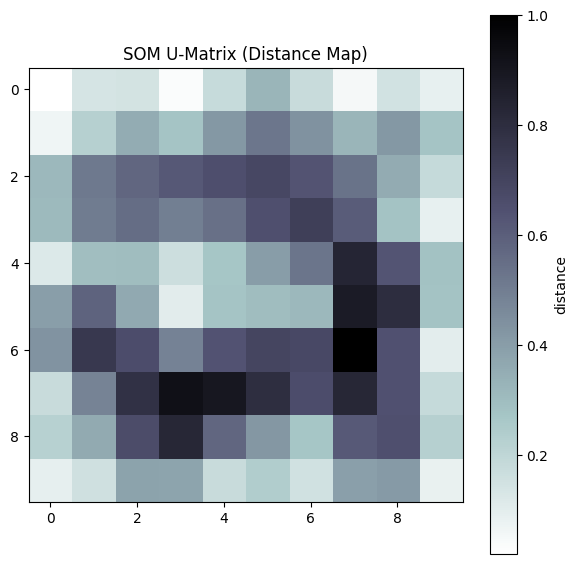

In [45]:
# ---------------------------------------------------------
# 5) Visualize the SOM
# ---------------------------------------------------------
# Option A: Plot the distance map (UMatrix) to see how the SOM organizes distances

plt.figure(figsize=(7,7))
plt.title("SOM U-Matrix (Distance Map)")
umatrix = som.distance_map()
plt.imshow(umatrix, cmap = 'bone_r')
plt.colorbar(label = "distance")

# 7. DELTA RULE
- **Delta Rule:** A gradient descent approach to adjust weights in a single-layer neural network so as to minimize squared error between predicted and target outputs.

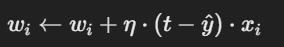

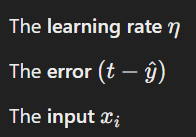

In [46]:
import numpy as np

In [50]:
X = np.array([
    [1,2],
    [2,3],
    [3,4]
], dtype = float)

t = np.array([3,5,7], dtype = float) # t ==> target variable

In [51]:
# hyper parameters
eta = 0.01         # learning rate
epochs = 100       # max number of epochs

weights = np.random.rand(2)
print("INITAL WEIGHTS ::", weights)

INITAL WEIGHTS :: [0.75902825 0.07568025]


In [52]:
# delta rule

for epoch in range(epochs):
    total_error = 0.0
    
    for i in range(len(X)):
        # 1) get the input and target
        
        x_i = X[i]
        target = t[i]
        
        # 2) prediction
        predicted = np.dot(weights, x_i)
        
        # 3) Error
        error = target - predicted
        
        # 4) weight update (DELTA RULE)
        weights = weights + eta * error * x_i
        
        # 5) Accumulate error
        total_error += error **2
        
    # Optional: Stop early if error is very small
    if total_error < 0.0001:
        print(f"Stopped Early at epoch {epoch}.")
        break
        
print("Final Weights ::", weights)

Final Weights :: [1.22912964 0.83849143]
